In [2]:
import numpy as np 
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Problem 1

There are methods for plotting the surface and contour plots of $f(x, y) = z$. You do not need to worry about modifying the code, but feel free to play around with it! 


I also recommend you to learn how to make basic plots with MatPlotLib in general. Here is a [quick start guide](https://matplotlib.org/stable/users/explain/quick_start.html), but I would honestly suggest asking an LLM chatbot on how to use basic functionalities like plot(), scatter(), and other functionalities like setting the titles, axis labels, and the legend. 

In [3]:
def config_3d(f, box_length, elev=30, azim=45):
    """
    Plots a 3D plot of f(x, y) = z
    """
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    x = np.linspace(-box_length, box_length, 100) # Create a x-axis 
    y = np.linspace(-box_length, box_length, 100) # Create a y-axis 
    X, Y = np.meshgrid(x, y) # Create a 2D xy grid
    Z = f(X, Y) # evaluate f(x, y) at each point of the meshgrid

    ax.plot_surface(X, Y, Z) # plot the f(x, y) grid surface
    
    ax.set_xlim(-1 * box_length, box_length)
    ax.set_ylim(-1 * box_length, box_length)
    ax.set_zlim(np.min(Z), np.max(Z))
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    
    ax.view_init(elev, azim) # set angle


def contour(f, box_length):
    """
    Plot a contour plot of f(x, y) = z
    """
    x = np.linspace(-box_length, box_length, 100)
    y = np.linspace(-box_length, box_length, 100)
    X, Y = np.meshgrid(x, y)
    Z = f(X, Y)

    fig, ax = plt.subplots()
    contour = ax.contour(x, y, Z, 50) # plot contour plot
    plt.colorbar(contour) # add color bar
    ax.set_xlabel('x')
    ax.set_ylabel('y')

## Problem 2.1 (a)

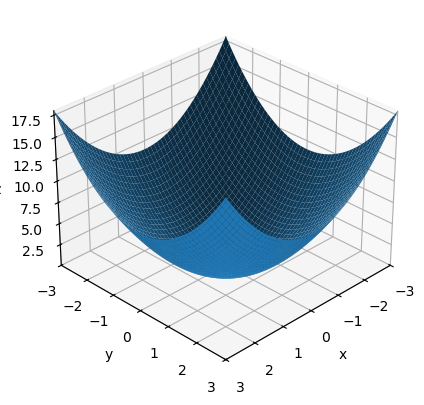

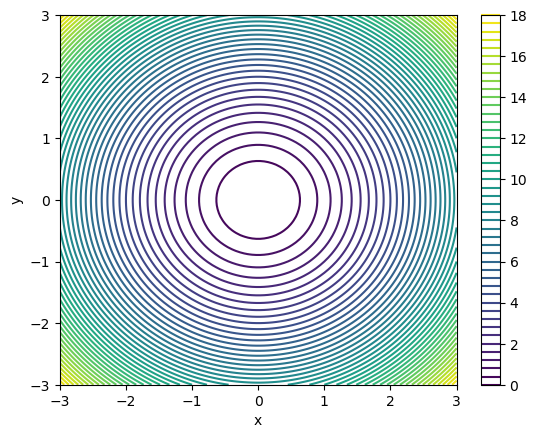

In [6]:
def f_parabola(x, y):
    return x**2 + y**2

box_length = 3

config_3d(f_parabola, box_length) # 3d plot
contour(f_parabola, box_length) # contous plot

## Problem 2.1 (b)

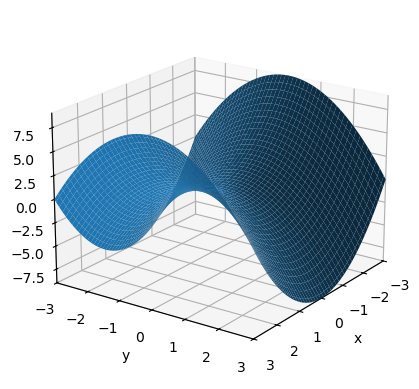

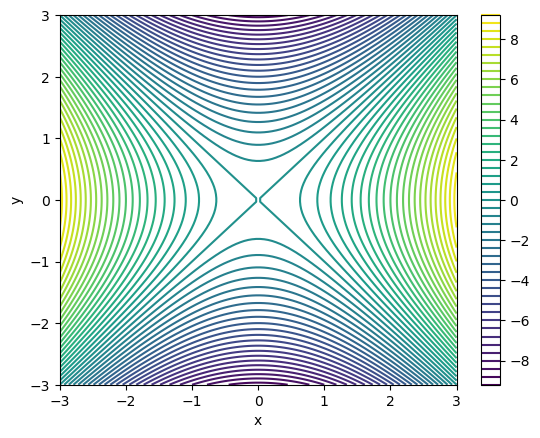

In [5]:
def f_saddle(x, y):
    return x**2 - y**2

box_length = 3

config_3d(f_saddle, box_length, elev=20, azim=35) # 3D plot with derivative lines
contour(f_saddle, box_length) # contour plot

# Problem 3

## Problem 3.1 (a)

In [8]:
A = np.array([ # construct the matrix from the linear system
    [1, 3, 2], 
    [2, 2, 2], 
    [3, 5, 6]
])

x_1 = np.array([1, 1, 0]) # construct the first vector
b_1 = A @ x_1

b_1

array([4, 4, 8])

In [9]:
x_2 = np.array([2, 1, -3])
b_2 = A @ x_2

b_2

array([-1,  0, -7])

Note that $@$ and $*$ are different operations in NumPy. For standard matrix-vector, matrix-matrix, and vector-vector multiplication, use $@$. 

In [11]:
b_1_times = A * x_1
print(b_1_times)

b_2_times = A * x_2
print(b_2_times)

[[1 3 0]
 [2 2 0]
 [3 5 0]]
[[  2   3  -6]
 [  4   2  -6]
 [  6   5 -18]]


## Problem 3.1 (b)

In [12]:
A = np.array([
    [2, -1, 3], 
    [0, 4, 5], 
    [-2, 1, 1]
])
B = np.array([
    [1, 2, 0], 
    [-3, 1, 4], 
    [2, -1, 3]
])
C = A @ B

C

array([[11,  0,  5],
       [-2, -1, 31],
       [-3, -4,  7]])

## Problem 3.1 (c)

In [14]:
A = np.array([
    [3, -2], 
    [5, 1]
])
B = np.array([
    [4, -1], 
    [0, 7],
    [-3, 2]
])

A_inverse = np.linalg.inv(A)
A_inverse

array([[ 0.07692308,  0.15384615],
       [-0.38461538,  0.23076923]])

In [17]:
A @ A_inverse

array([[1.00000000e+00, 0.00000000e+00],
       [5.55111512e-17, 1.00000000e+00]])

In [15]:
B_tranpose = B.T
B_tranpose

array([[ 4,  0, -3],
       [-1,  7,  2]])

In [16]:
B_tranpose = np.linalg.matrix_transpose(B)
B_tranpose

array([[ 4,  0, -3],
       [-1,  7,  2]])

## Problem 3.2 (a)

In [26]:
x = np.array([3, -1, 2, 1])
x_norm = np.linalg.norm(x)
x_normalized = x / x_norm

print(f'norm(x): {x_norm}')
print(f'normalized_x: {x_normalized}')
print(f'norm of normalized_x{np.linalg.norm(x_normalized)}\n')


A = np.array([
    [2, 1], 
    [-1, 3]
])
A_norm = np.linalg.norm(A, 'fro')
A_normalized = A / A_norm

print(f'frobenius norm of matrix A: {A_norm}')
print(f'Normalized matrix A: {A_normalized}')
print(f'norm of normalized A: {np.linalg.norm(A_normalized, 'fro')}\n')

norm(x): 3.872983346207417
normalized_x: [ 0.77459667 -0.25819889  0.51639778  0.25819889]
norm of normalized_x1.0

frobenius norm of matrix A: 3.872983346207417
Normalized matrix A: [[ 0.51639778  0.25819889]
 [-0.25819889  0.77459667]]
norm of normalized A: 1.0



## Problem 3.3 (a)

In [32]:
A = np.array([
    [1, 3, 2], 
    [2, 2, 2], 
    [3, 5, 6]
])

eigenvalues, eigenvectors = np.linalg.eig(A)

[[eigenval, eigenvec] for eigenval, eigenvec in zip(eigenvalues, eigenvectors)]

[[np.float64(9.123105625617663),
  array([-0.34176197, -0.80655913, -0.47466201])],
 [np.float64(-1.0000000000000004),
  array([-0.34176197,  0.58658846, -0.47466201])],
 [np.float64(0.8768943743823393),
  array([-0.87544133, -0.07332356,  0.74120979])]]